**Principal Component Analysis**
| Mouse |Gene1|Gene2|Gene3|Gene4|
|---|---|---|---|---|
| 1 | 10 | 6 | 1.2 | 5|
| 2 | 11 | 4 | 9 | 7|
| 3 | 8 | 5 | 10 |6 |
| 4 | 3 | 3 | 2.5| 2|
| 5 | 1 | 2.8|1.3|4|
| 6 | 2 | 1 | 2 | 7|

If we only measure Gene 1 how do I separate the mice?

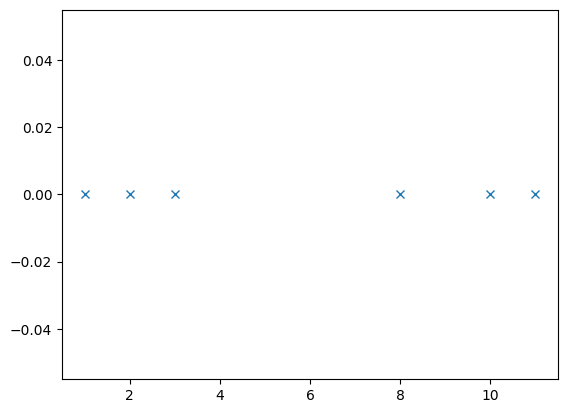

In [1]:
import numpy as np
from matplotlib import pyplot as plt
gene1 = [10, 11, 8, 3, 1, 2]
plt.plot(gene1, np.zeros_like(gene1), 'x')

Mice 1, 2 and 3 are more similar to each other than they are to mice 4, 5, and 6. Lets 2 genes.

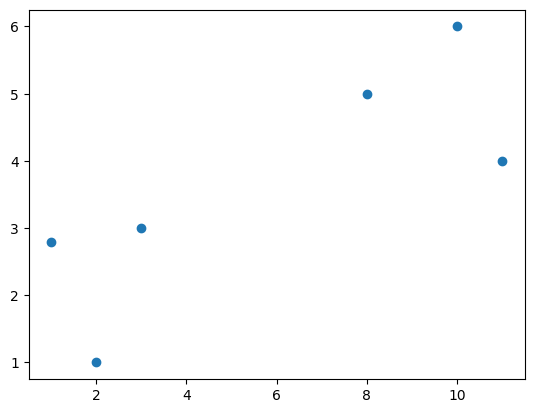

In [3]:
gene2 = [6, 4, 5, 3, 2.8, 1]
plt.scatter(gene1, gene2)

- PCA can tell us which gene or variable or combination of variables is the most valuable for clustering
- To understand PCA we will use dataset with the first two genes

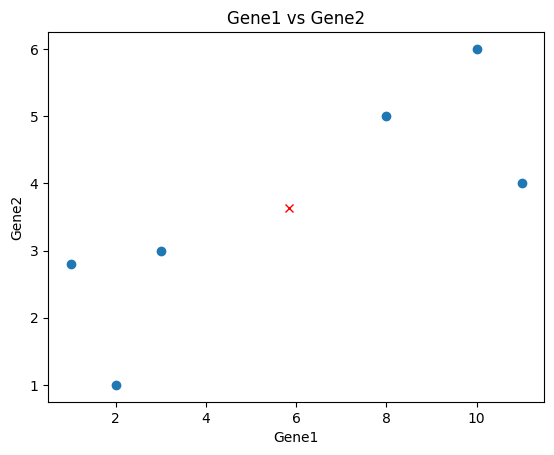

In [4]:
plt.scatter(gene1, gene2)
plt.title("Gene1 vs Gene2")
plt.xlabel("Gene1")
plt.ylabel("Gene2")
gene1average = np.average(gene1)
gene2average = np.average(gene2)
plt.plot(gene1average, gene2average, 'rx')

- We will shift the data so that the centre is at the origin
- We do this by subtracting the average from every point

In [5]:
gene1 = gene1 - gene1average
gene2 = gene2 - gene2average
print(gene1)
print(gene2)

[ 4.16666667  5.16666667  2.16666667 -2.83333333 -4.83333333 -3.83333333]
[ 2.36666667  0.36666667  1.36666667 -0.63333333 -0.83333333 -2.63333333]


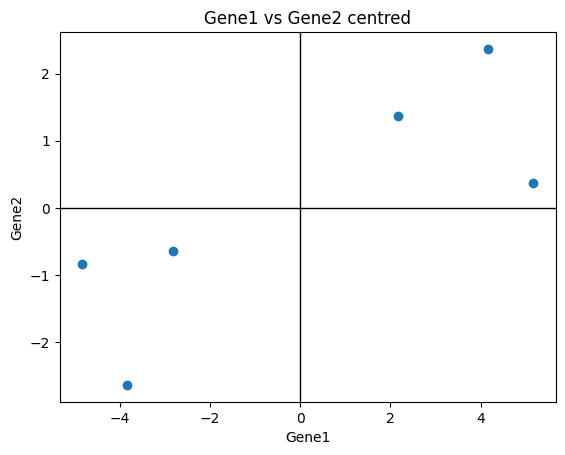

In [7]:
plt.scatter(gene1, gene2)
plt.title("Gene1 vs Gene2 centred")
plt.xlabel("Gene1")
plt.ylabel("Gene2")
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

- Shifting the data did not change how the points are positioned relative to each other
- Now that the data is centred at the origin we can fit a line to it
- Start with a random line through the origin and rotate until it fits as good as possible
- We need to consider how PCA decides if a fit is good or not
- Consider a random starting line through the origin
- To quantify how good this line fits the data, PCA will project the data onto the line and then it will measure the distances from the data to the line and try and find the line that minimises the distances or
- It can try and find the line that maximises the distances of from the projected points to the origin
- $a^2 = b^2 + c^2$, since $a$ is fixed, as $b$ gets smaller $c$ gets bigger and vice versa
- PCA can either minimise $b$ or maximise $c$
- Intuitively it more obvious to minimise $b$... but it is easier to calculate $c$, the distance from the projected point to the origin, so PCA finds the best line by minimising the squared distances of the projected point to the origin
- Rotate the line to find the largest SS
- This line is called Principal Component 1 or PC1 for short

In [8]:
from scipy import stats
slope, intercept, _, _, _ = stats.linregress(gene1, gene2)
print(slope)
print(intercept)

0.32302284710017576
-1.6964884226316686e-16


- PC1 has slope 0.323. In other words for every 3 units we go along the gene1 axis, we go up one in the gene2 axis
- This means that the data is mostly spread out along gene1 and only a little spread out along gene2
- To make PC1, we take 3 parts gene1 and 1 part gene2
- The ratio of gene1 to gene2 tells you that gene1 is more important when it comes to describing how the data is spread out
- PC1 is a **linear combination** of gene1 and gene2
- When you do PCA using Singular Value Decomposition (SVD), the recipe for PC1 is scaled so that its length is 1. In our case we need to divide by $\sqrt(10)$
- PC1 = $\frac{3}{\sqrt(10)}gene1 + \frac{1}{\sqrt(10)}gene2$
- The unit vector is called the singular vector or the eigenvector of PC1
- The proportions of each gene care called "Loading Scores"
- PCA calls the average of the SS distances for the best fit line the eigenvalue for PC1
- $\frac{SS(distances for PC1)}{n-1}$ = Eigenvalue for PC1
- $\sqrt{SS(distances for PC1)}$ = Singular value for PC1
- Because our example is 2D, PC2 is the line that goes through the origin, perpendicular to PC1
- PC2 = -1gene1 + 3 gene2
- Scaling PC2 to get unit vector $\frac{-1}{\sqrt{10}}gene1 + \frac{3}{\sqrt{10}}gene2$
- For PC2 gene2 is three times more important than gene1
- To draw the final PCA plot rotate everything so that PC1 is horizontal. Then we can use the projected points to see where the samples are in the PCA plot.
- Eigenvalues are measures of variation
- For the sake of this example that variation for PC1 is 15 and the variation for PC2 is 3.
- Total variation = 18
- This means that PC1 accounts for 15/18 = 83% of the total variation around PCs
- A scree plot is a graphical representation of percentages of variation that each PC accounts for
- Kaiser criterion says that we should retain PCs who eignevalue > 1

**PCA with 3 variables**
- Centre the data
- Find the line of best fit through the origin - PC1
- PC1 = 0.62gene1 + 0.15gene2+0.77gene3
- PC2 is next best fitting line that goes through the origin and is at right angles to PC1
- PC3 is the next best fitting line through the origin that is orthogonal to PC1 and PC2
- In theory there is one PC per gene (or variable) but in practice the number of PCs is either the number of variables of the number of samples whichever is smaller
- One we have all of the PCs we can use the eigenvalues to determine the proportion of the variation that the PC accounts for
- Suppose PC1 79%, PC2 15%, PC3 6%

In [9]:
import pandas as pd
import numpy as np
import random as rd
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt

In [14]:
genes = ['gene'+str(i) for i in range(1, 101)]
wt = ['wt'+str(i) for i in range(1, 6)]
ko = ['ko'+str(i) for i in range(1, 6)]

In [15]:
data  = pd.DataFrame(columns=[*wt, *ko], index = genes)
data

,wt1,wt2,wt3,wt4,wt5,ko1,ko2,ko3,ko4,ko5
gene1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
gene96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
for gene in data.index:
    data.loc[gene, 'wt1':'wt5'] = np.random.poisson(lam=rd.randrange(10, 1000), size = 5)
    data.loc[gene, 'ko1':'ko5'] = np.random.poisson(lam=rd.randrange(10, 1000), size = 5)

In [18]:
print(data.head())

       wt1  wt2  wt3  wt4  wt5  ko1  ko2  ko3  ko4  ko5
gene1  224  214  224  236  225  773  781  782  753  779
gene2  489  478  486  500  492  604  565  567  590  581
gene3  554  593  557  519  595  667  700  706  616  674
gene4  140  149  143  156  129  115  104  117  116  131
gene5  159  141  139  129  130  557  653  571  609  572


In [19]:
print(data.shape)

(100, 10)


In [20]:
scaled_data = preprocessing.scale(data.T)

In [21]:
scaled_data

array([[-1.00163933, -0.97041693, -1.02931686,  0.62329799, -0.90842963,
         0.74959184, -0.98883702, -0.99578687, -0.96781577, -0.98362915,
        -0.91938194,  0.93156852,  0.95810969,  1.13601394,  0.90408349,
        -1.03752095, -0.96436455,  1.1029409 ,  0.23649062, -1.27409358,
        -0.86022605,  0.34649612, -0.99360766, -0.15649027,  1.09426163,
        -1.05756902, -1.04542689,  1.79380824,  0.50563522,  0.90883842,
         0.9834042 , -1.07253774, -0.73024779, -1.05148949,  1.00057511,
         0.21712936, -0.99740699,  0.54579021, -0.94570871, -1.05273825,
        -1.38419851,  1.1179924 ,  1.13539246, -0.98457436,  0.8020347 ,
         0.9816301 , -0.98041676, -0.96562494, -1.05395743, -0.05044181,
        -0.01308   , -1.12978728,  0.66056503, -1.00592221,  1.00225479,
        -0.45472486, -0.98332075, -0.79111049,  1.00482094, -1.01006553,
        -0.10591667,  1.43075019, -0.93936126,  1.57144872,  1.05221554,
        -1.00319831, -1.98928227, -1.00890529,  1.1

In [25]:
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)
per_var = np.round(pca.explained_variance_ratio_ *100, decimals=1)
per_var

array([88.2,  2.9,  2. ,  1.8,  1.7,  1.1,  0.9,  0.7,  0.6,  0. ])

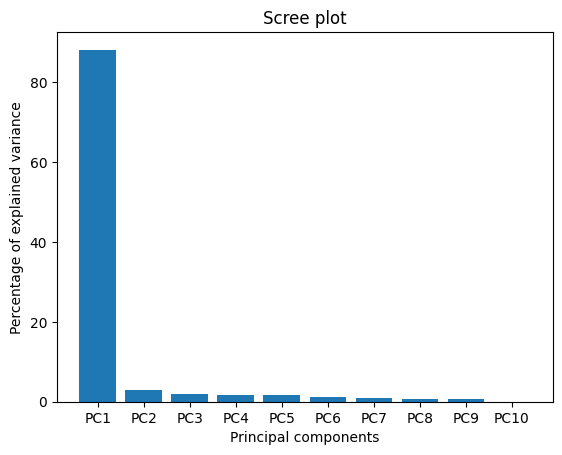

In [28]:
labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]
plt.bar(x = range(1, len(per_var)+1), height = per_var, tick_label=labels)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principal components")
plt.title("Scree plot")
plt.show()

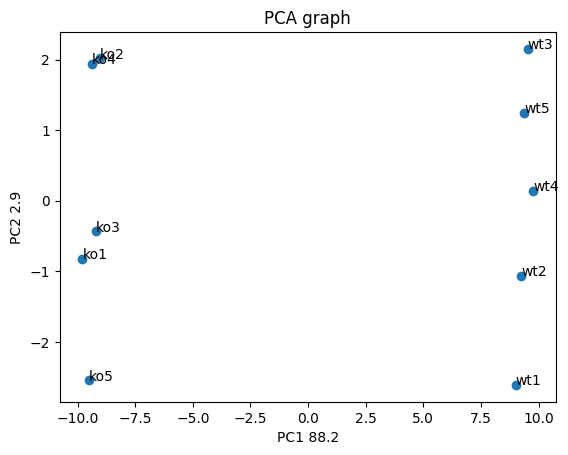

In [30]:
pca_df = pd.DataFrame(pca_data, index=[*wt, *ko], columns = labels)
plt.scatter(pca_df.PC1, pca_df.PC2)
plt.title("PCA graph")
plt.xlabel(f'PC1 {per_var[0]}')
plt.ylabel(f'PC2 {per_var[1]}')
for sample in pca_df.index:
    plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]))
plt.show()


In [31]:
loading_scores = pd.Series(pca.components_[0], index = genes)
print(*loading_scores)

-0.10634128270402493 -0.10357674598252377 -0.09318245396079812 0.08889390129384397 -0.10564109808042538 0.10468815607001836 -0.10632797678313172 -0.10627287625881822 -0.10617182509001058 -0.10541047232207668 -0.10569761986572739 0.10609557820080537 0.10635680759812823 0.10580609523563579 0.10507223239995339 -0.10637992657502467 -0.10621077495177146 0.09513482180180925 0.0722191467050151 -0.10347606768598964 -0.10528173929304199 -0.08475938116049235 -0.1033716253796151 0.07983277110262178 0.10624761812783728 -0.10635664785563166 -0.10210165588464225 0.08090412603911075 0.09023192342955803 0.10515007518551067 0.10641500449794164 -0.10611012847749816 -0.10152790519502863 -0.10549733679254769 0.10642799293840072 0.04757298903006997 -0.06746236491183841 0.10401393120707296 -0.10633854961445509 -0.10258793141819936 -0.06563331454961098 0.10616585960810523 0.10615821297219889 -0.1064080620813917 0.10343762407584474 0.10625887950850565 0.005296405802715862 -0.1062936633709266 -0.10615316241211

In [32]:
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)
top_10_genes = sorted_loading_scores[0:10].index.values
top_10_genes

<StringArray>
['gene35', 'gene71', 'gene31', 'gene44', 'gene81', 'gene16', 'gene54',
 'gene84', 'gene60', 'gene13']
Length: 10, dtype: str